In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("../data/onlinefoods.csv")

In [9]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    str    
 2   Marital Status              388 non-null    str    
 3   Occupation                  388 non-null    str    
 4   Monthly Income              388 non-null    str    
 5   Educational Qualifications  388 non-null    str    
 6   Family size                 388 non-null    int64  
 7   latitude                    388 non-null    float64
 8   longitude                   388 non-null    float64
 9   Pin code                    388 non-null    int64  
 10  Output                      388 non-null    str    
 11  Feedback                    388 non-null    str    
 12  Unnamed: 12                 388 non-null    str    
dtypes: float64(2), int64(3), str(8)
memory usage: 

In [11]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Output', 'Feedback', 'Unnamed: 12'],
      dtype='str')

In [12]:
df.describe()

,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [13]:
import matplotlib.pyplot as plt

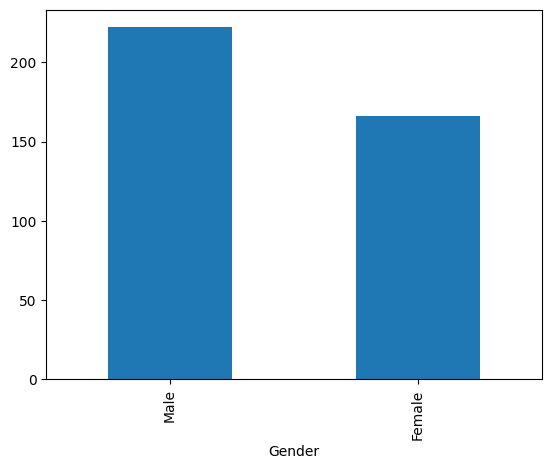

In [14]:
df["Gender"].value_counts().plot(kind="bar")
plt.show()

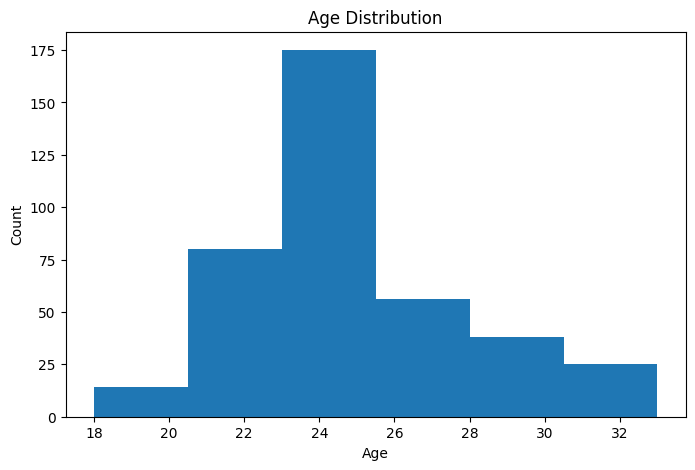

In [15]:
plt.figure(figsize=(8,5))

df["Age"].plot(kind="hist", bins=6)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")

plt.show()

## 연령 분포 분석

- 20대 사용자가 가장 많았다.
- 특정 연령대에 주문이 집중되는 경향을 확인하였다.

In [16]:
pd.crosstab(df["Occupation"], df["Output"])

Output,No,Yes
Occupation,,
Employee,42,76
House wife,2,7
Self Employeed,20,34
Student,23,184


- Student가 주문 많이 함
- Employee도 높음

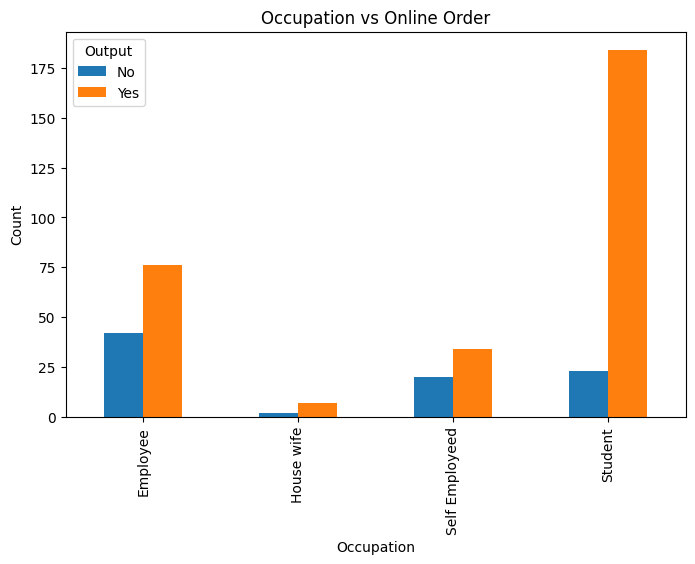

In [17]:
pd.crosstab(df["Occupation"], df["Output"]).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Occupation vs Online Order")
plt.xlabel("Occupation")
plt.ylabel("Count")

plt.show()

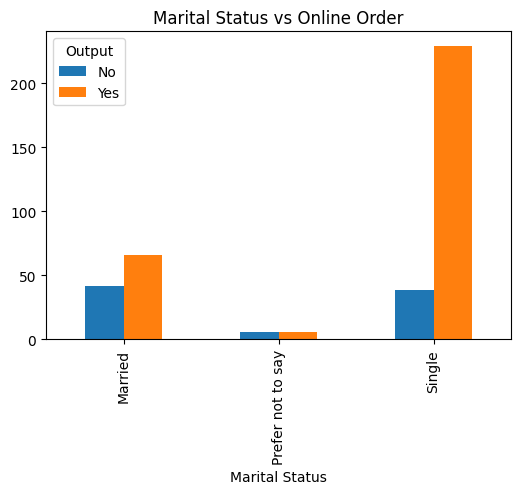

In [18]:
#결혼 유무와 주문관계
pd.crosstab(df["Marital Status"], df["Output"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Marital Status vs Online Order")

plt.show()

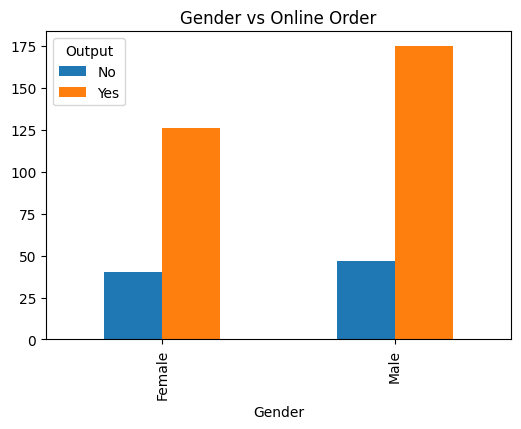

In [19]:
#성별과 주문관계
pd.crosstab(df["Gender"], df["Output"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Gender vs Online Order")

plt.show()

## 주문 패턴 분석 결과

- Student 그룹의 온라인 주문 비율이 가장 높게 나타났다.
- Single 사용자의 주문 비율이 높았다.
- 성별에 따른 주문 차이는 크지 않았다.

In [20]:
numeric_df = df.select_dtypes(include="number")

In [21]:
numeric_df.head()

,Age,Family size,latitude,longitude,Pin code
0,20,4,12.9766,77.5993,560001
1,24,3,12.9770,77.5773,560009
2,22,3,12.9551,77.6593,560017
3,22,6,12.9473,77.5616,560019
4,22,4,12.9850,77.5533,560010


In [22]:
#상관관계 계산
numeric_df.corr()

,Age,Family size,latitude,longitude,Pin code
Age,1.000000,0.169982,0.006595,0.047500,0.137294
Family size,0.169982,1.000000,-0.053537,0.070126,-0.009402
latitude,0.006595,-0.053537,1.000000,-0.144234,-0.201813
longitude,0.047500,0.070126,-0.144234,1.000000,0.156119
Pin code,0.137294,-0.009402,-0.201813,0.156119,1.000000


| 값  | 의미          |
| -- | ----------- |
| 1  | 매우 강한 양의 관계 |
| 0  | 관계 거의 없음    |
| -1 | 반대 관계       |


In [23]:
import seaborn as sns

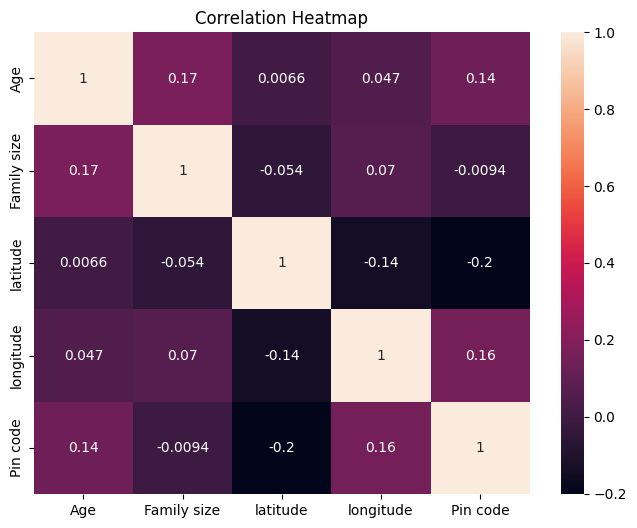

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [29]:
import sqlite3

In [30]:
conn = sqlite3.connect("../data/delivery.db")

In [31]:
df.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

388

In [32]:
query = """
SELECT *
FROM orders
LIMIT 5
"""

In [33]:
pd.read_sql(query, conn)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


In [34]:
#직업별 사용자 수 분석
query = """
SELECT Occupation,
       COUNT(*) AS user_count
FROM orders
GROUP BY Occupation
ORDER BY user_count DESC
"""

In [35]:
pd.read_sql(query, conn)

,Occupation,user_count
0,Student,207
1,Employee,118
2,Self Employeed,54
3,House wife,9


In [36]:
#성별별 사용자 수
query = """
SELECT Gender,
       COUNT(*) AS count
FROM orders
GROUP BY Gender
"""

In [37]:
pd.read_sql(query, conn)

,Gender,count
0,Female,166
1,Male,222


In [38]:
#온라인 주문 여부 분석
query = """
SELECT Output,
       COUNT(*) AS count
FROM orders
GROUP BY Output
"""

In [39]:
pd.read_sql(query, conn)

,Output,count
0,No,87
1,Yes,301


In [40]:
#평균나이 분석
query = """
SELECT AVG(Age) AS average_age
FROM orders
"""

In [41]:
pd.read_sql(query, conn)

,average_age
0,24.628866


In [42]:
#직업별 평균 나이
query = """
SELECT Occupation,
       AVG(Age) AS average_age
FROM orders
GROUP BY Occupation
ORDER BY average_age DESC
"""

In [43]:
pd.read_sql(query, conn)

,Occupation,average_age
0,House wife,30.333333
1,Employee,26.576271
2,Self Employeed,26.388889
3,Student,22.811594


In [44]:
#결혼 여부별 주문 분석
query = """
SELECT `Marital Status`,
       Output,
       COUNT(*) AS count
FROM orders
GROUP BY `Marital Status`, Output
"""

In [45]:
pd.read_sql(query, conn)

,Marital Status,Output,count
0,Married,No,42
1,Married,Yes,66
2,Prefer not to say,No,6
3,Prefer not to say,Yes,6
4,Single,No,39
5,Single,Yes,229


In [46]:
query = """
SELECT Occupation,
       COUNT(*) AS user_count
FROM orders
GROUP BY Occupation
"""

result = pd.read_sql(query, conn)

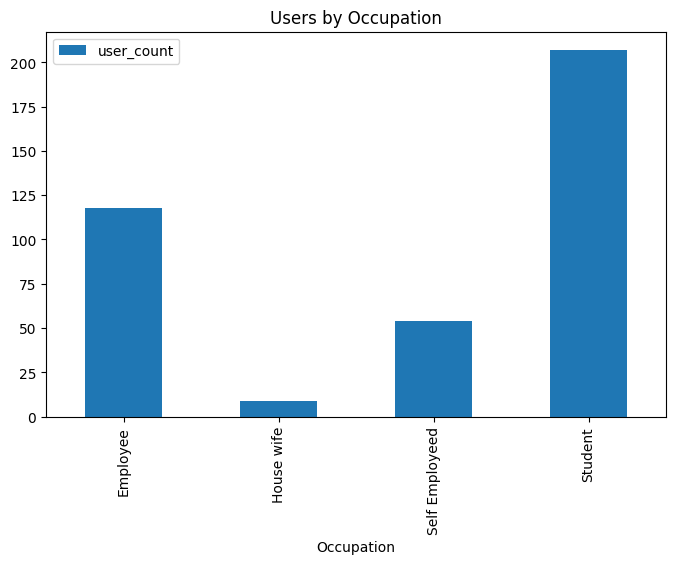

In [47]:
result.plot(
    x="Occupation",
    y="user_count",
    kind="bar",
    figsize=(8,5)
)

plt.title("Users by Occupation")

plt.show()

## SQL 분석 결과

- Student 직업군 비율이 가장 높게 나타났다.
- 평균 연령은 약 25세로 확인되었다.
- 온라인 주문 비율이 전체적으로 높았다.